<a href="https://colab.research.google.com/github/HirofumiAOKI/ballet-pose-detection/blob/main/ballet_pose_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ===================================
# バレエ・ダンス研究用 骨格検出ツール
# Ballet Pose Detection with MediaPipe
# ===================================

# Step 1: 必要なライブラリをインストール
!pip install mediapipe -q

print("インストール完了！")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 94.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 12.3 MB/s eta 0:00:00
インストール完了！


In [2]:
# Step 2: モデルのダウンロード
import urllib.request
import os

model_path = "pose_landmarker.task"
if not os.path.exists(model_path):
    print("モデルをダウンロード中...（約30秒かかります）")
    url = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/latest/pose_landmarker_heavy.task"
    urllib.request.urlretrieve(url, model_path)
    print("ダウンロード完了！")
else:
    print("モデルはすでに存在します！")

モデルをダウンロード中...（約30秒かかります）
ダウンロード完了！


分析したい画像をアップロードしてください


Saving 02.png to 02.png
アップロードされた画像：02.png
1人の骨格を検出しました！


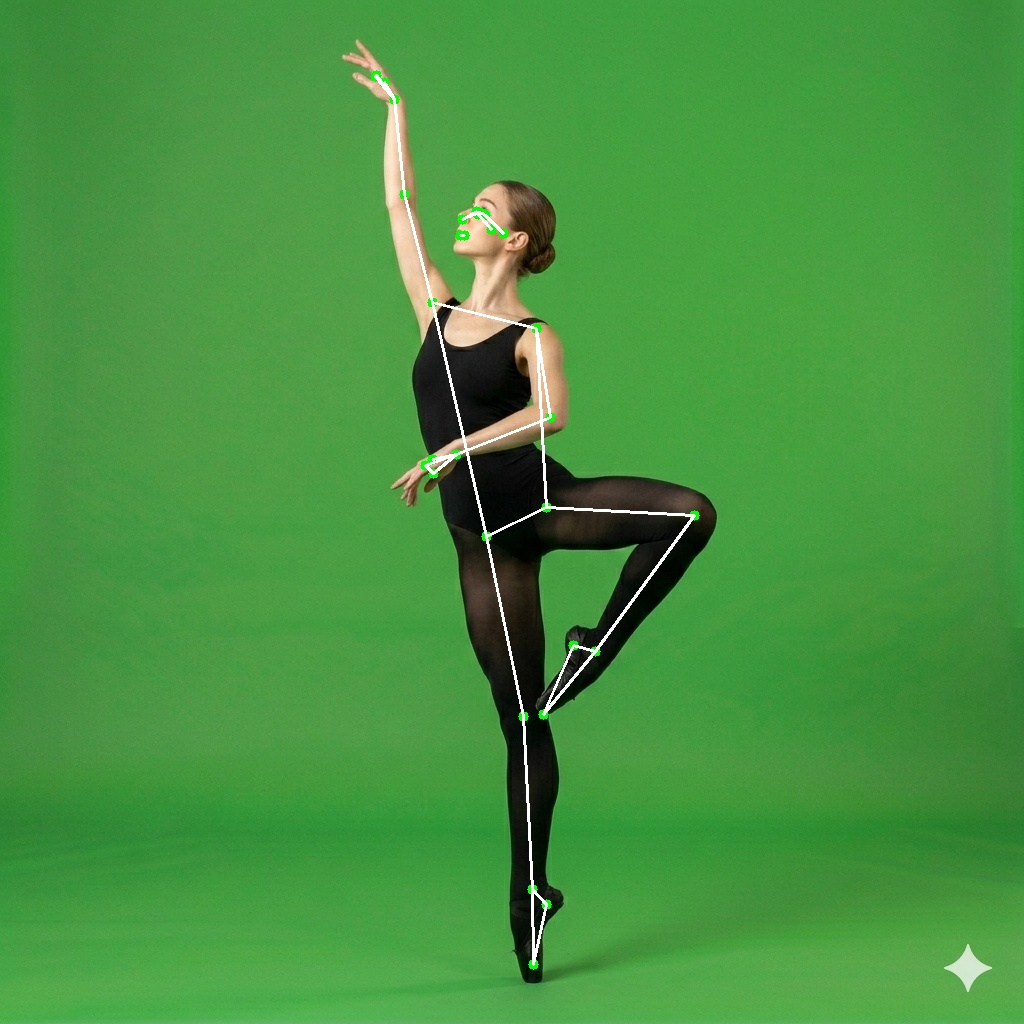

完了！


In [4]:
# Step 3: 画像をアップロードして骨格検出
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from google.colab import files
from IPython.display import display, Image
import numpy as np

# 画像をアップロード
print("分析したい画像をアップロードしてください")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
print(f"アップロードされた画像：{image_path}")

# 骨格の接続定義
POSE_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,7),(0,4),(4,5),(5,6),(6,8),
    (9,10),(11,12),(11,13),(13,15),(15,17),(15,19),(15,21),
    (17,19),(12,14),(14,16),(16,18),(16,20),(16,22),(18,20),
    (11,23),(12,24),(23,24),(23,25),(24,26),(25,27),(26,28),
    (27,29),(28,30),(29,31),(30,32),(27,31),(28,32)
]

# 骨格検出
base_options = python.BaseOptions(model_asset_path="pose_landmarker.task")
options = vision.PoseLandmarkerOptions(base_options=base_options)
image = mp.Image.create_from_file(image_path)
cv_image = cv2.imread(image_path)

with vision.PoseLandmarker.create_from_options(options) as landmarker:
    result = landmarker.detect(image)

# 描画
if result.pose_landmarks:
    print(f"{len(result.pose_landmarks)}人の骨格を検出しました！")
    annotated = cv_image.copy()
    h, w = cv_image.shape[:2]
    for landmarks in result.pose_landmarks:
        for lm in landmarks:
            x, y = int(lm.x * w), int(lm.y * h)
            cv2.circle(annotated, (x, y), 5, (0, 255, 0), -1)
        for connection in POSE_CONNECTIONS:
            start = landmarks[connection[0]]
            end = landmarks[connection[1]]
            x1, y1 = int(start.x * w), int(start.y * h)
            x2, y2 = int(end.x * w), int(end.y * h)
            cv2.line(annotated, (x1, y1), (x2, y2), (255, 255, 255), 2)

    # 結果を表示
    result_path = "result.jpg"
    cv2.imwrite(result_path, annotated)
    display(Image(result_path))
    print("完了！")
else:
    print("骨格が検出できませんでした")